# Operações em Grandes Volumes - Censo Escolar

Consultas com agrupamentos, incrementos graduais de volume e gráficos, considerando o contrato definido em `2-schema-pandera-censo-escolar.ipynb`.

A base só possui a dimensão temporal `ano_censo`; por isso, os incrementos graduais são acumulados por ano: `1995`, `1995-1996`, ..., `1995-2025`. Todas as consultas leem `censo-escolar.csv` em batches para não carregar os 7,3 milhões de registros em memória.

## 1) Configuração

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import pandas as pd

RAIZ_PROJETO = Path.cwd()
if not (RAIZ_PROJETO / 'trabalho').exists() and (RAIZ_PROJETO.parent / 'trabalho').exists():
    RAIZ_PROJETO = RAIZ_PROJETO.parent

CSV_PATH = RAIZ_PROJETO / 'trabalho' / 'censo-escolar.csv'
DIR_SAIDA = RAIZ_PROJETO / 'trabalho' / 'operacoes_grandes_volumes'
DIR_GRAFICOS = DIR_SAIDA / 'graficos'
BATCH_SIZE = 200_000

DIR_GRAFICOS.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    raise FileNotFoundError(f'CSV consolidado não encontrado: {CSV_PATH}')

print(f'Fonte: {CSV_PATH}')
print(f'Tamanho: {CSV_PATH.stat().st_size / 1024**2:.1f} MB')
print(f'Batch size: {BATCH_SIZE:,} linhas')
print(f'Saída: {DIR_SAIDA}')

Fonte: /home/gabriel/ciencias-computacao/programacao-para-analise-de-dados/trabalho/censo-escolar.csv
Tamanho: 1074.8 MB
Batch size: 200,000 linhas
Saída: /home/gabriel/ciencias-computacao/programacao-para-analise-de-dados/trabalho/operacoes_grandes_volumes


## 2) Colunas do Schema e Regras Usadas nas Consultas

As consultas abaixo reaproveitam os grupos de colunas do schema Pandera: identificadores, domínios categóricos, indicadores binários, quantidades e regras RN de consistência.

In [2]:
COLUNAS_ESPERADAS = [
    'ano_censo', 'id_escola', 'co_municipio', 'no_municipio', 'sg_uf', 'co_uf', 'no_uf',
    'no_regiao', 'co_regiao', 'no_entidade', 'dependencia_administrativa', 'localizacao',
    'situacao_funcionamento', 'tp_localizacao_diferenciada', 'tp_categoria_escola_privada',
    'in_regular', 'in_creche', 'in_pre_escola', 'in_fundamental', 'in_medio', 'in_eja',
    'in_profissionalizante', 'in_especial', 'in_educacao_indigena', 'in_predio_escolar',
    'in_predio_compartilhado', 'in_agua_potavel', 'in_agua_rede_publica',
    'in_agua_poco_artesiano', 'in_agua_inexistente', 'in_energia_rede_publica',
    'in_energia_gerador', 'in_energia_inexistente', 'qt_mat_bas', 'qt_mat_fund',
    'qt_mat_med', 'qt_doc_bas', 'qt_doc_fund', 'qt_doc_med', 'qt_tur_bas',
    'qt_tur_fund', 'qt_tur_med',
]

COLUNAS_IN = [coluna for coluna in COLUNAS_ESPERADAS if coluna.startswith('in_')]
COLUNAS_QT = [coluna for coluna in COLUNAS_ESPERADAS if coluna.startswith('qt_')]
COLUNAS_CATEGORICAS = [
    'dependencia_administrativa', 'localizacao', 'situacao_funcionamento',
]
COLUNAS_COMPLETUDE = [coluna for coluna in COLUNAS_ESPERADAS if coluna != 'ano_censo']
COLUNAS_NUMERICAS = [
    'ano_censo', 'co_uf', 'co_regiao', 'tp_localizacao_diferenciada',
    'tp_categoria_escola_privada', *COLUNAS_IN, *COLUNAS_QT,
]

colunas_csv = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
faltantes = [coluna for coluna in COLUNAS_ESPERADAS if coluna not in colunas_csv]
extras = [coluna for coluna in colunas_csv if coluna not in COLUNAS_ESPERADAS]

print(f'Colunas esperadas: {len(COLUNAS_ESPERADAS)}')
print(f'Colunas no CSV: {len(colunas_csv)}')
print(f'Colunas ausentes: {faltantes}')
print(f'Colunas extras: {extras}')

if faltantes or extras:
    raise ValueError('O CSV não corresponde ao contrato de 42 colunas do schema.')

Colunas esperadas: 42
Colunas no CSV: 42
Colunas ausentes: []
Colunas extras: []


## 3) Funções de Leitura e Acumulação

A cada batch, o notebook converte apenas as colunas necessárias para contas numéricas e atualiza acumuladores pequenos. O maior objeto em memória continua sendo o batch atual.

In [3]:
def preparar_lote(lote):
    lote = lote.copy()
    for coluna in COLUNAS_NUMERICAS:
        if coluna in lote.columns:
            lote[coluna] = pd.to_numeric(lote[coluna], errors='coerce')
    return lote.dropna(subset=['ano_censo']).assign(ano_censo=lambda df: df['ano_censo'].astype('Int64'))

def acumular_df(acumulador, parcial, chaves):
    if parcial is None or parcial.empty:
        return acumulador
    if acumulador is None:
        return parcial.copy()
    return (
        pd.concat([acumulador, parcial], ignore_index=True)
        .groupby(chaves, as_index=False, dropna=False)
        .sum(numeric_only=True)
    )

def ler_batches():
    return pd.read_csv(
        CSV_PATH,
        usecols=COLUNAS_ESPERADAS,
        dtype='string',
        chunksize=BATCH_SIZE,
        low_memory=False,
    )

def serie_tamanho_texto(serie):
    return serie.astype('string').str.len()

def regras_consistencia_lote(lote):
    ano = lote['ano_censo']
    tam_id = serie_tamanho_texto(lote['id_escola'])
    tam_municipio = serie_tamanho_texto(lote['co_municipio'])
    loc_dif = lote['tp_localizacao_diferenciada']

    rn02_valida = ((ano == 1995) & tam_id.eq(10)) | ((ano >= 1996) & tam_id.eq(8))
    rn03_valida = ((ano == 1995) & tam_municipio.eq(14)) | (ano.between(1996, 2006) & tam_municipio.eq(12)) | ((ano >= 2007) & tam_municipio.eq(7))
    rn04_valida = (
        loc_dif.isna()
        | (ano.between(1995, 2011) & loc_dif.isin([0, 1, 2, 3]))
        | (ano.between(2012, 2018) & loc_dif.isin([0, 1, 2, 3, 4, 5, 6]))
        | (ano.between(2019, 2022) & loc_dif.isin([0, 1, 2, 3]))
        | (ano.between(2023, 2025) & loc_dif.isin([0, 1, 2, 3, 8]))
    )

    return {
        'RN-02_id_escola_tamanho': lote['id_escola'].notna() & ~rn02_valida,
        'RN-03_municipio_tamanho': lote['co_municipio'].notna() & ~rn03_valida,
        'RN-04_localizacao_diferenciada': ~rn04_valida,
        'RN-05_ativa_sem_matricula_basica': (ano >= 2007) & lote[['situacao_funcionamento', 'qt_mat_bas']].notna().all(axis=1) & lote['situacao_funcionamento'].eq('Ativa') & lote['qt_mat_bas'].le(0),
        'RN-06_agua_inexistente_e_rede': lote[['in_agua_inexistente', 'in_agua_rede_publica']].notna().all(axis=1) & lote['in_agua_inexistente'].eq(1) & lote['in_agua_rede_publica'].eq(1),
        'RN-07_energia_inexistente_e_rede': lote[['in_energia_inexistente', 'in_energia_rede_publica']].notna().all(axis=1) & lote['in_energia_inexistente'].eq(1) & lote['in_energia_rede_publica'].eq(1),
        'RN-08_matricula_total_menor_partes': (ano >= 2007) & lote[['qt_mat_bas', 'qt_mat_fund', 'qt_mat_med']].notna().all(axis=1) & lote['qt_mat_bas'].lt(lote['qt_mat_fund'] + lote['qt_mat_med']),
        'RN-09_doc_fund_maior_bas': lote[['qt_doc_bas', 'qt_doc_fund']].notna().all(axis=1) & lote['qt_doc_fund'].gt(lote['qt_doc_bas']),
        'RN-10_doc_med_maior_bas': lote[['qt_doc_bas', 'qt_doc_med']].notna().all(axis=1) & lote['qt_doc_med'].gt(lote['qt_doc_bas']),
        'RN-11_tur_fund_maior_bas': lote[['qt_tur_bas', 'qt_tur_fund']].notna().all(axis=1) & lote['qt_tur_fund'].gt(lote['qt_tur_bas']),
        'RN-12_tur_med_maior_bas': lote[['qt_tur_bas', 'qt_tur_med']].notna().all(axis=1) & lote['qt_tur_med'].gt(lote['qt_tur_bas']),
        'RN-13_fund_sem_indicador': lote[['in_fundamental', 'qt_mat_fund']].notna().all(axis=1) & lote['qt_mat_fund'].gt(0) & lote['in_fundamental'].ne(1),
        'RN-14_medio_sem_indicador': lote[['in_medio', 'qt_mat_med']].notna().all(axis=1) & lote['qt_mat_med'].gt(0) & lote['in_medio'].ne(1),
        'RN-15_turma_fund_sem_matricula': lote[['qt_mat_fund', 'qt_tur_fund']].notna().all(axis=1) & lote['qt_tur_fund'].gt(0) & lote['qt_mat_fund'].le(0),
        'RN-16_turma_med_sem_matricula': lote[['qt_mat_med', 'qt_tur_med']].notna().all(axis=1) & lote['qt_tur_med'].gt(0) & lote['qt_mat_med'].le(0),
    }

## 4) Execução das Consultas Pesadas em Batches

Esta etapa faz uma varredura completa no CSV e calcula simultaneamente:

- perfil anual da base;
- completude das 42 colunas do schema por ano;
- agrupamento por `ano_censo`, `dependencia_administrativa`, `localizacao` e `situacao_funcionamento`;
- disponibilidade e somas das colunas `in_` e `qt_`;
- falhas por ano para as regras RN-02 a RN-16.

A regra RN-01 de duplicidade exata de `(ano_censo, id_escola)` não é recalculada aqui para não manter um conjunto de milhões de chaves em memória.

In [4]:
inicio = time.perf_counter()
linhas_lidas = 0
perfil_anual = None
nulos_por_ano = None
agrupamento_categorico = None
indicadores_quantidades = None
falhas_regras = None

for numero_batch, lote in enumerate(ler_batches(), start=1):
    lote = preparar_lote(lote)
    linhas_lidas += len(lote)

    parcial_perfil = lote.groupby('ano_censo').agg(
        linhas=('ano_censo', 'size'),
        escolas_com_id=('id_escola', 'count'),
        municipios_com_codigo=('co_municipio', 'count'),
        escolas_ativas=('situacao_funcionamento', lambda s: s.eq('Ativa').sum()),
        escolas_paralisadas=('situacao_funcionamento', lambda s: s.isin(['Paralisada', 'Paralisado']).sum()),
        escolas_extintas=('situacao_funcionamento', lambda s: s.isin(['Extinta', 'Extinto']).sum()),
    ).reset_index()
    perfil_anual = acumular_df(perfil_anual, parcial_perfil, ['ano_censo'])

    parcial_nulos = lote.groupby('ano_censo')[COLUNAS_COMPLETUDE].apply(lambda df: df.isna().sum()).reset_index()
    nulos_por_ano = acumular_df(nulos_por_ano, parcial_nulos, ['ano_censo'])

    parcial_categorias = (
        lote.groupby(['ano_censo', *COLUNAS_CATEGORICAS], dropna=False)
        .agg(
            escolas=('id_escola', 'count'),
            qt_mat_bas=('qt_mat_bas', 'sum'),
            qt_doc_bas=('qt_doc_bas', 'sum'),
            qt_tur_bas=('qt_tur_bas', 'sum'),
        )
        .reset_index()
    )
    agrupamento_categorico = acumular_df(agrupamento_categorico, parcial_categorias, ['ano_censo', *COLUNAS_CATEGORICAS])

    somas = lote.groupby('ano_censo')[COLUNAS_IN + COLUNAS_QT].sum(min_count=1).add_prefix('soma_')
    preenchidos = lote.groupby('ano_censo')[COLUNAS_IN + COLUNAS_QT].count().add_prefix('preenchidos_')
    parcial_indicadores = somas.join(preenchidos).reset_index()
    indicadores_quantidades = acumular_df(indicadores_quantidades, parcial_indicadores, ['ano_censo'])

    partes_falhas = []
    for regra, mascara in regras_consistencia_lote(lote).items():
        parcial_regra = lote.loc[mascara].groupby('ano_censo').size().rename('falhas').reset_index()
        if not parcial_regra.empty:
            parcial_regra['regra'] = regra
            partes_falhas.append(parcial_regra)
    if partes_falhas:
        parcial_falhas = pd.concat(partes_falhas, ignore_index=True)
        falhas_regras = acumular_df(falhas_regras, parcial_falhas, ['ano_censo', 'regra'])

    if numero_batch % 5 == 0:
        print(f'Batch {numero_batch}: {linhas_lidas:,} linhas processadas')

tempo = time.perf_counter() - inicio
print(f'Linhas processadas: {linhas_lidas:,}')
print(f'Tempo total: {tempo:.1f}s')

Batch 5: 1,000,000 linhas processadas
Batch 10: 2,000,000 linhas processadas
Batch 15: 3,000,000 linhas processadas
Batch 20: 4,000,000 linhas processadas
Batch 25: 5,000,000 linhas processadas
Batch 30: 6,000,000 linhas processadas
Batch 35: 7,000,000 linhas processadas
Linhas processadas: 7,376,443
Tempo total: 71.1s


## 5) Consulta 1: Perfil Anual e Incremento Gradual do Volume

In [5]:
perfil_anual = perfil_anual.sort_values('ano_censo').reset_index(drop=True)
perfil_anual['pct_ativas'] = perfil_anual['escolas_ativas'] / perfil_anual['linhas']
perfil_anual['pct_paralisadas'] = perfil_anual['escolas_paralisadas'] / perfil_anual['linhas']
perfil_anual['pct_extintas'] = perfil_anual['escolas_extintas'] / perfil_anual['linhas']

incrementos_volume = perfil_anual.copy()
for coluna in ['linhas', 'escolas_com_id', 'municipios_com_codigo', 'escolas_ativas', 'escolas_paralisadas', 'escolas_extintas']:
    incrementos_volume[f'acum_{coluna}'] = incrementos_volume[coluna].cumsum()
incrementos_volume['periodo'] = '1995-' + incrementos_volume['ano_censo'].astype(str)
incrementos_volume['pct_acum_ativas'] = incrementos_volume['acum_escolas_ativas'] / incrementos_volume['acum_linhas']

display(perfil_anual)
display(incrementos_volume[['periodo', 'acum_linhas', 'acum_escolas_com_id', 'acum_municipios_com_codigo', 'pct_acum_ativas']])

,ano_censo,linhas,escolas_com_id,municipios_com_codigo,escolas_ativas,escolas_paralisadas,escolas_extintas,pct_ativas,pct_paralisadas,pct_extintas
0,1995,243637,243637,243637,222355,17570,3712,0.912649,0.072115,0.015236
1,1996,276731,276731,276731,223936,30501,22294,0.809219,0.110219,0.080562
2,1997,273951,273951,273951,225520,30200,18231,0.823213,0.110239,0.066548
3,1998,267532,267532,267532,215120,37169,15243,0.804091,0.138933,0.056976
4,1999,266645,266645,266645,217362,35777,13506,0.815174,0.134175,0.050652
5,2000,261988,261988,261988,217412,34967,9609,0.829855,0.133468,0.036677
6,2001,264735,264735,264735,218383,29795,16557,0.824912,0.112547,0.062542
7,2002,256986,256986,256986,214188,30998,11800,0.833462,0.120621,0.045917
8,2003,253405,253405,253405,211933,31222,10250,0.836341,0.12321,0.040449
9,2004,248257,248257,248257,210094,30001,8162,0.846276,0.120847,0.032877


,periodo,acum_linhas,acum_escolas_com_id,acum_municipios_com_codigo,pct_acum_ativas
0,1995-1995,243637,243637,243637,0.912649
1,1995-1996,520368,520368,520368,0.857645
2,1995-1997,794319,794319,794319,0.84577
3,1995-1998,1061851,1061851,1061851,0.835269
4,1995-1999,1328496,1328496,1328496,0.831235
5,1995-2000,1590484,1590484,1590484,0.831008
6,1995-2001,1855219,1855219,1855219,0.830138
7,1995-2002,2112205,2112205,2112205,0.830542
8,1995-2003,2365610,2365610,2365610,0.831164
9,1995-2004,2613867,2613867,2613867,0.832599


## 6) Consulta 2: Completude das 42 Colunas do Schema por Ano

Esta consulta mostra quando cada coluna passou a ter dados disponíveis. Ela é importante porque o schema é canônico para 1995-2025, mas várias colunas só existem em anos mais recentes.

In [6]:
linhas_por_ano = perfil_anual[['ano_censo', 'linhas']]
completude_por_ano = nulos_por_ano.merge(linhas_por_ano, on='ano_censo').sort_values('ano_censo')
for coluna in COLUNAS_COMPLETUDE:
    completude_por_ano[coluna] = 1 - (completude_por_ano[coluna] / completude_por_ano['linhas'])

resumo_completude = pd.DataFrame({
    'ano_censo': completude_por_ano['ano_censo'],
    'linhas': completude_por_ano['linhas'],
    'colunas_com_algum_dado': 1 + (completude_por_ano[COLUNAS_COMPLETUDE] > 0).sum(axis=1),
    'media_completude': (1 + completude_por_ano[COLUNAS_COMPLETUDE].sum(axis=1)) / len(COLUNAS_ESPERADAS),
})

display(resumo_completude)
display(completude_por_ano[['ano_censo', 'id_escola', 'co_municipio', 'co_uf', 'no_regiao', 'qt_mat_bas', 'qt_doc_bas', 'in_agua_potavel', 'in_energia_rede_publica']])

,ano_censo,linhas,colunas_com_algum_dado,media_completude
0,1995,243637,14,0.333271
1,1996,276731,14,0.333333
2,1997,273951,23,0.518077
3,1998,267532,24,0.538783
4,1999,266645,24,0.540632
5,2000,261988,24,0.520107
6,2001,264735,26,0.569112
7,2002,256986,26,0.571168
8,2003,253405,26,0.574253
9,2004,248257,27,0.607056


,ano_censo,id_escola,co_municipio,co_uf,no_regiao,qt_mat_bas,qt_doc_bas,in_agua_potavel,in_energia_rede_publica
0,1995,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1996,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1997,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.822746
3,1998,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.804128
4,1999,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.815234
5,2000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.827244
6,2001,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.824912
7,2002,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.833466
8,2003,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.836341
9,2004,1.0,1.0,0.0,0.0,0.0,0.0,0.846276,0.84626


## 7) Consulta 3: Agrupamento por Domínios Categóricos do Schema

Agrupamento pesado por `ano_censo`, `dependencia_administrativa`, `localizacao` e `situacao_funcionamento`, os três principais domínios categóricos validados pelo Pandera.

In [7]:
agrupamento_categorico = agrupamento_categorico.sort_values(['ano_censo', *COLUNAS_CATEGORICAS]).reset_index(drop=True)
agrupamento_categorico['matriculas_por_escola'] = agrupamento_categorico['qt_mat_bas'] / agrupamento_categorico['escolas']

top_categorias_2025 = (
    agrupamento_categorico[agrupamento_categorico['ano_censo'].eq(2025)]
    .sort_values('escolas', ascending=False)
    .head(15)
)

display(agrupamento_categorico.head(20))
display(top_categorias_2025)

,ano_censo,dependencia_administrativa,localizacao,situacao_funcionamento,escolas,qt_mat_bas,qt_doc_bas,qt_tur_bas,matriculas_por_escola
0,1995,Estadual,Rural,Ativa,20718,0.0,0.0,0.0,0.0
1,1995,Estadual,Rural,Extinto,204,0.0,0.0,0.0,0.0
2,1995,Estadual,Rural,Paralisado,1550,0.0,0.0,0.0,0.0
3,1995,Estadual,Urbana,Ativa,30187,0.0,0.0,0.0,0.0
4,1995,Estadual,Urbana,Extinto,52,0.0,0.0,0.0,0.0
5,1995,Estadual,Urbana,Paralisado,301,0.0,0.0,0.0,0.0
6,1995,Federal,Rural,Ativa,133,0.0,0.0,0.0,0.0
7,1995,Federal,Rural,Extinto,1,0.0,0.0,0.0,0.0
8,1995,Federal,Rural,Paralisado,47,0.0,0.0,0.0,0.0
9,1995,Federal,Urbana,Ativa,143,0.0,0.0,0.0,0.0


,ano_censo,dependencia_administrativa,localizacao,situacao_funcionamento,escolas,qt_mat_bas,qt_doc_bas,qt_tur_bas,matriculas_por_escola
653,2025,Municipal,Urbana,Ativa,63062,18881760.0,1171632.0,885154.0,299.415813
650,2025,Municipal,Rural,Ativa,44310,4177408.0,323697.0,267442.0,94.276868
659,2025,Privada,Urbana,Ativa,41784,9151031.0,644586.0,545746.0,219.008017
643,2025,Estadual,Urbana,Ativa,24310,12504518.0,727364.0,464104.0,514.37754
652,2025,Municipal,Rural,Paralisada,15375,0.0,0.0,0.0,0.0
661,2025,Privada,Urbana,Paralisada,7701,0.0,0.0,0.0,0.0
640,2025,Estadual,Rural,Ativa,5688,825784.0,77645.0,51466.0,145.180028
655,2025,Municipal,Urbana,Paralisada,3129,0.0,0.0,0.0,0.0
651,2025,Municipal,Rural,Extinta,1961,0.0,0.0,0.0,0.0
645,2025,Estadual,Urbana,Paralisada,1801,0.0,0.0,0.0,0.0


## 8) Consulta 4: Indicadores e Quantidades por Ano

Resume as colunas `in_` e `qt_` do schema: totais, disponibilidade e razões úteis, como matrículas por docente e turmas por docente.

In [8]:
indicadores_quantidades = indicadores_quantidades.merge(linhas_por_ano, on='ano_censo').sort_values('ano_censo')
for coluna in COLUNAS_IN + COLUNAS_QT:
    indicadores_quantidades[f'pct_preenchido_{coluna}'] = indicadores_quantidades[f'preenchidos_{coluna}'] / indicadores_quantidades['linhas']

indicadores_quantidades['matriculas_por_docente'] = indicadores_quantidades['soma_qt_mat_bas'] / indicadores_quantidades['soma_qt_doc_bas']
indicadores_quantidades['turmas_por_docente'] = indicadores_quantidades['soma_qt_tur_bas'] / indicadores_quantidades['soma_qt_doc_bas']
indicadores_quantidades['pct_escolas_com_creche'] = indicadores_quantidades['soma_in_creche'] / indicadores_quantidades['linhas']
indicadores_quantidades['pct_escolas_com_medio'] = indicadores_quantidades['soma_in_medio'] / indicadores_quantidades['linhas']

display(indicadores_quantidades[[
    'ano_censo', 'linhas', 'soma_qt_mat_bas', 'soma_qt_doc_bas', 'soma_qt_tur_bas',
    'matriculas_por_docente', 'turmas_por_docente', 'pct_escolas_com_creche',
    'pct_escolas_com_medio', 'pct_preenchido_qt_mat_bas',
]])

,ano_censo,linhas,soma_qt_mat_bas,soma_qt_doc_bas,soma_qt_tur_bas,matriculas_por_docente,turmas_por_docente,pct_escolas_com_creche,pct_escolas_com_medio,pct_preenchido_qt_mat_bas
0,1995,243637,0.0,0.0,0.0,<NA>,<NA>,0.0,0.06348,0.0
1,1996,276731,0.0,0.0,0.0,<NA>,<NA>,0.0,0.054934,0.0
2,1997,273951,0.0,0.0,0.0,<NA>,<NA>,0.033794,0.04795,0.0
3,1998,267532,0.0,0.0,0.0,<NA>,<NA>,0.039319,0.055119,0.0
4,1999,266645,0.0,0.0,0.0,<NA>,<NA>,0.069767,0.062176,0.0
5,2000,261988,0.0,0.0,0.0,<NA>,<NA>,0.07984,0.068866,0.0
6,2001,264735,0.0,0.0,0.0,<NA>,<NA>,0.096213,0.072605,0.0
7,2002,256986,0.0,0.0,0.0,<NA>,<NA>,0.10441,0.079985,0.0
8,2003,253405,0.0,0.0,0.0,<NA>,<NA>,0.110712,0.084505,0.0
9,2004,248257,0.0,0.0,0.0,<NA>,<NA>,0.121914,0.092352,0.0


## 9) Consulta 5: Falhas das Regras RN do Schema por Ano

Conta, por ano, as linhas que violam regras de consistência equivalentes às regras RN-02 a RN-16 do notebook Pandera.

In [9]:
if falhas_regras is None:
    falhas_regras = pd.DataFrame(columns=['ano_censo', 'regra', 'falhas'])

falhas_regras = falhas_regras.merge(linhas_por_ano, on='ano_censo', how='left')
falhas_regras['pct_linhas'] = falhas_regras['falhas'] / falhas_regras['linhas']
falhas_regras = falhas_regras.sort_values(['ano_censo', 'regra']).reset_index(drop=True)

resumo_falhas = (
    falhas_regras.groupby('regra', as_index=False)
    .agg(total_falhas=('falhas', 'sum'), anos_afetados=('ano_censo', 'nunique'), maior_pct_anual=('pct_linhas', 'max'))
    .sort_values('total_falhas', ascending=False)
)

falhas_por_ano = (
    falhas_regras.groupby('ano_censo', as_index=False)
    .agg(total_falhas=('falhas', 'sum'))
    .merge(linhas_por_ano, on='ano_censo')
)
falhas_por_ano['falhas_por_mil_linhas'] = 1000 * falhas_por_ano['total_falhas'] / falhas_por_ano['linhas']

display(resumo_falhas)
display(falhas_por_ano)
display(falhas_regras.head(30))

,regra,total_falhas,anos_afetados,maior_pct_anual
0,RN-05_ativa_sem_matricula_basica,38554,14,0.029556
1,RN-13_fund_sem_indicador,1575,1,0.007353
2,RN-14_medio_sem_indicador,1142,1,0.005332
3,RN-16_turma_med_sem_matricula,285,1,0.001331


,ano_censo,total_falhas,linhas,falhas_por_mil_linhas
0,2008,5938,205699,28.867423
1,2009,5987,203455,29.426655
2,2010,5937,200876,29.555547
3,2011,1885,242147,7.784528
4,2012,2019,242136,8.338289
5,2013,1972,242680,8.125927
6,2014,1880,242929,7.738887
7,2015,2248,237879,9.450183
8,2016,1810,237506,7.62086
9,2017,1780,236481,7.527032


,ano_censo,regra,falhas,linhas,pct_linhas
0,2008,RN-05_ativa_sem_matricula_basica,5938,205699,0.028867
1,2009,RN-05_ativa_sem_matricula_basica,5987,203455,0.029427
2,2010,RN-05_ativa_sem_matricula_basica,5937,200876,0.029556
3,2011,RN-05_ativa_sem_matricula_basica,1885,242147,0.007785
4,2012,RN-05_ativa_sem_matricula_basica,2019,242136,0.008338
5,2013,RN-05_ativa_sem_matricula_basica,1972,242680,0.008126
6,2014,RN-05_ativa_sem_matricula_basica,1880,242929,0.007739
7,2015,RN-05_ativa_sem_matricula_basica,2248,237879,0.00945
8,2016,RN-05_ativa_sem_matricula_basica,1810,237506,0.007621
9,2017,RN-05_ativa_sem_matricula_basica,1780,236481,0.007527


## 10) Gráficos

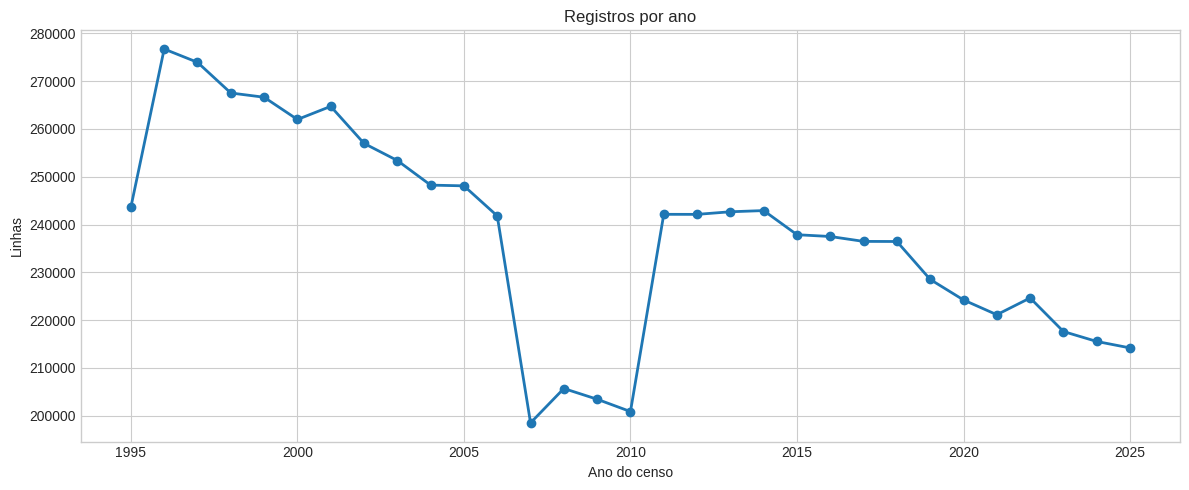

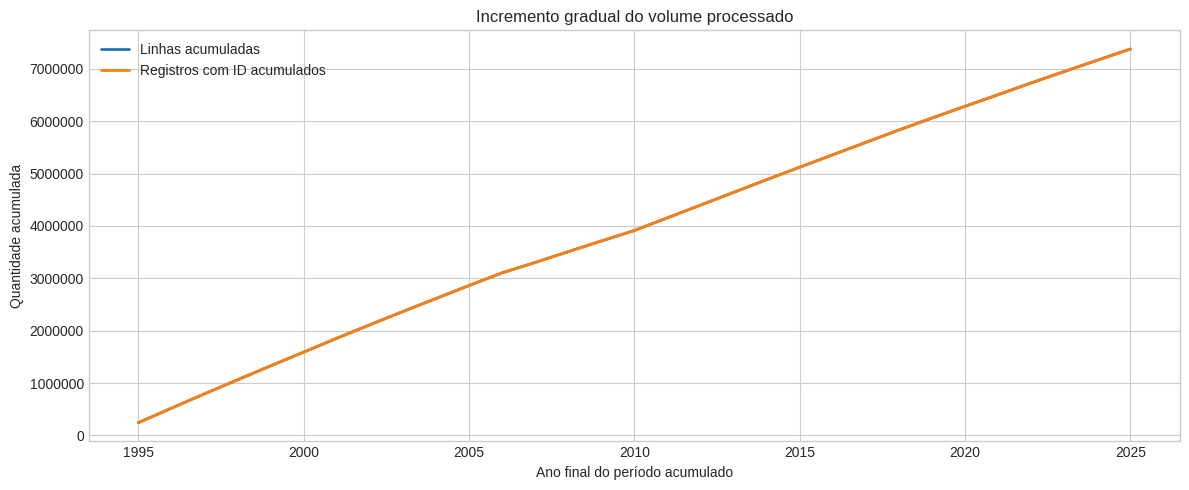

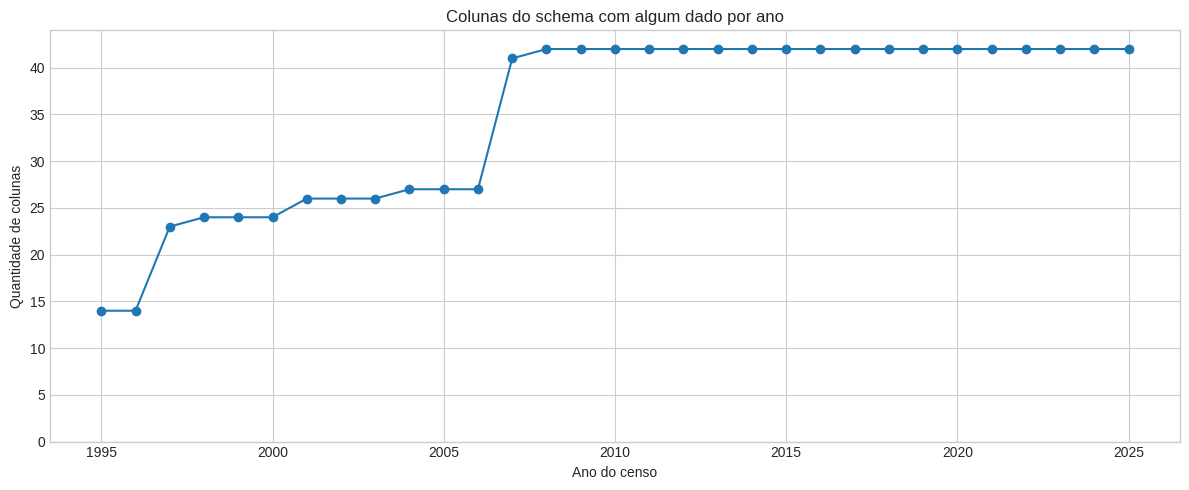

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(perfil_anual['ano_censo'], perfil_anual['linhas'], marker='o', linewidth=2)
ax.set_title('Registros por ano')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Linhas')
ax.ticklabel_format(style='plain', axis='y')
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '01_registros_por_ano.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(incrementos_volume['ano_censo'], incrementos_volume['acum_linhas'], label='Linhas acumuladas', linewidth=2)
ax.plot(incrementos_volume['ano_censo'], incrementos_volume['acum_escolas_com_id'], label='Registros com ID acumulados', linewidth=2)
ax.set_title('Incremento gradual do volume processado')
ax.set_xlabel('Ano final do período acumulado')
ax.set_ylabel('Quantidade acumulada')
ax.legend()
ax.ticklabel_format(style='plain', axis='y')
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '02_incremento_volume.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(resumo_completude['ano_censo'], resumo_completude['colunas_com_algum_dado'], marker='o')
ax.set_title('Colunas do schema com algum dado por ano')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Quantidade de colunas')
ax.set_ylim(0, len(COLUNAS_ESPERADAS) + 2)
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '03_colunas_disponiveis_por_ano.png', dpi=150)
plt.show()

TypeError: Image data of dtype object cannot be converted to float

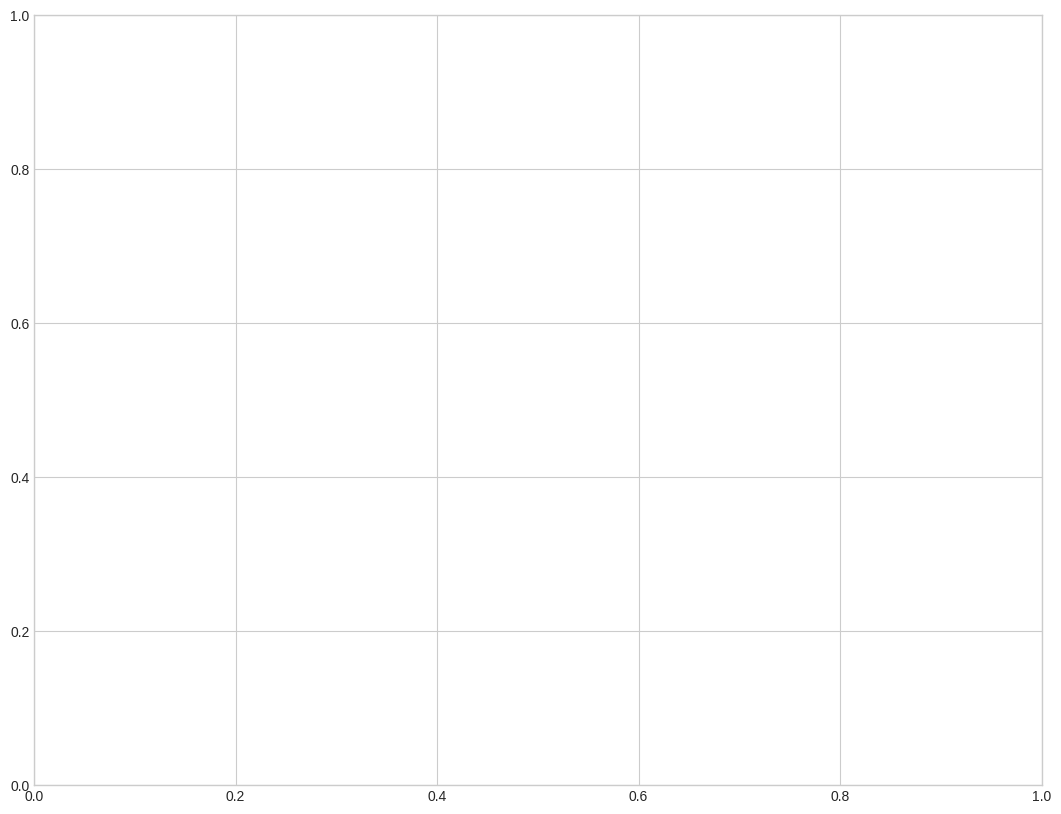

In [11]:
matriz_completude = completude_por_ano.set_index('ano_censo')[COLUNAS_COMPLETUDE].T
fig, ax = plt.subplots(figsize=(13, 10))
imagem = ax.imshow(matriz_completude, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_title('Mapa de completude das colunas do schema por ano')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Coluna')
ax.set_xticks(range(len(matriz_completude.columns)))
ax.set_xticklabels(matriz_completude.columns, rotation=90)
ax.set_yticks(range(len(matriz_completude.index)))
ax.set_yticklabels(matriz_completude.index, fontsize=8)
fig.colorbar(imagem, ax=ax, label='Completude')
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '04_mapa_completude_schema.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(indicadores_quantidades['ano_censo'], indicadores_quantidades['soma_qt_mat_bas'], label='Matrículas básicas', linewidth=2)
ax.plot(indicadores_quantidades['ano_censo'], indicadores_quantidades['soma_qt_doc_bas'], label='Docentes básicos', linewidth=2)
ax.plot(indicadores_quantidades['ano_censo'], indicadores_quantidades['soma_qt_tur_bas'], label='Turmas básicas', linewidth=2)
ax.set_title('Totais anuais de quantidades do schema')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Total')
ax.legend()
ax.ticklabel_format(style='plain', axis='y')
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '05_quantidades_por_ano.png', dpi=150)
plt.show()

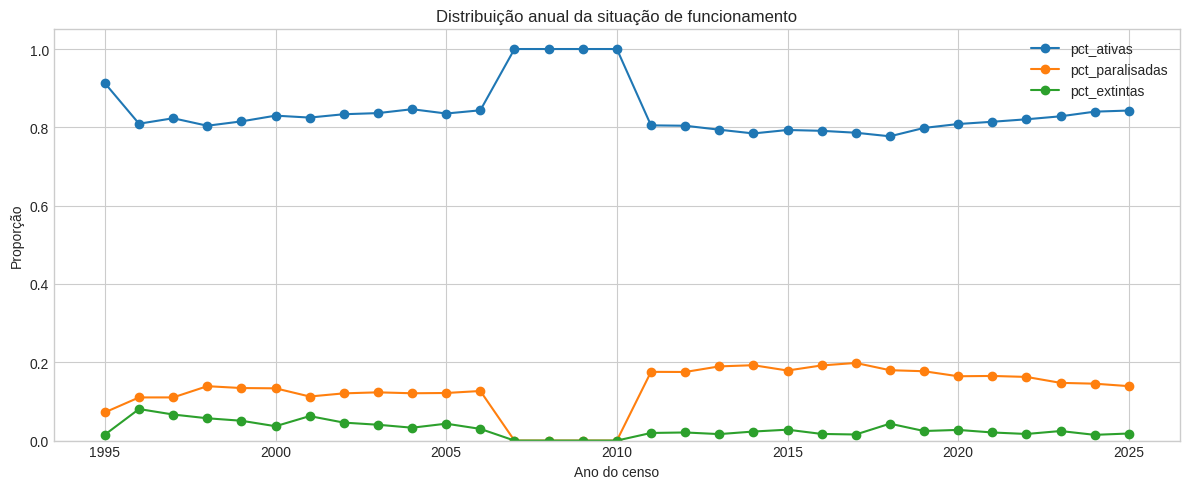

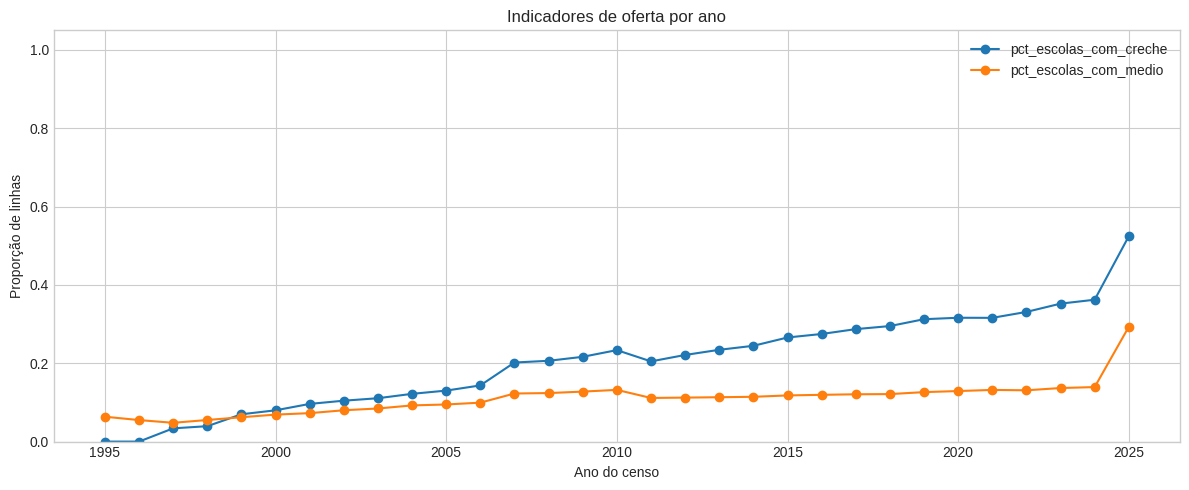

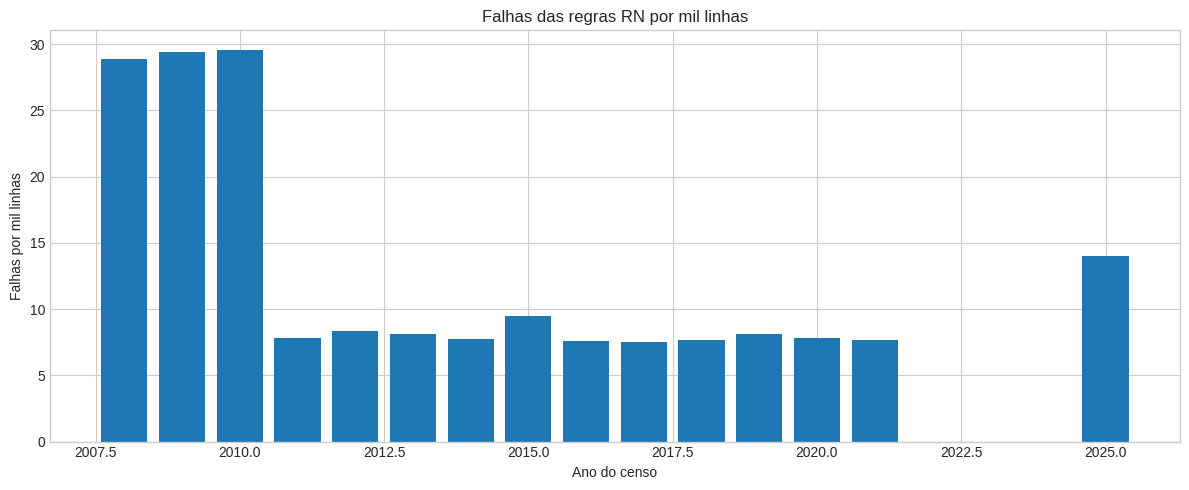

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for coluna in ['pct_ativas', 'pct_paralisadas', 'pct_extintas']:
    ax.plot(perfil_anual['ano_censo'], perfil_anual[coluna], marker='o', label=coluna)
ax.set_title('Distribuição anual da situação de funcionamento')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Proporção')
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '06_situacao_funcionamento.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for coluna in ['pct_escolas_com_creche', 'pct_escolas_com_medio']:
    ax.plot(indicadores_quantidades['ano_censo'], indicadores_quantidades[coluna], marker='o', label=coluna)
ax.set_title('Indicadores de oferta por ano')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Proporção de linhas')
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '07_indicadores_oferta.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(falhas_por_ano['ano_censo'], falhas_por_ano['falhas_por_mil_linhas'])
ax.set_title('Falhas das regras RN por mil linhas')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Falhas por mil linhas')
fig.tight_layout()
fig.savefig(DIR_GRAFICOS / '08_falhas_rn_por_ano.png', dpi=150)
plt.show()

## 11) Exportação dos Resultados Agregados

In [13]:
DIR_SAIDA.mkdir(parents=True, exist_ok=True)

perfil_anual.to_csv(DIR_SAIDA / 'perfil_anual.csv', index=False)
incrementos_volume.to_csv(DIR_SAIDA / 'incrementos_volume.csv', index=False)
resumo_completude.to_csv(DIR_SAIDA / 'resumo_completude_schema.csv', index=False)
completude_por_ano.to_csv(DIR_SAIDA / 'completude_colunas_por_ano.csv', index=False)
agrupamento_categorico.to_csv(DIR_SAIDA / 'agrupamento_categorico.csv', index=False)
indicadores_quantidades.to_csv(DIR_SAIDA / 'indicadores_quantidades.csv', index=False)
falhas_regras.to_csv(DIR_SAIDA / 'falhas_regras_schema.csv', index=False)
falhas_por_ano.to_csv(DIR_SAIDA / 'falhas_regras_por_ano.csv', index=False)

print('Resultados salvos em:')
print(DIR_SAIDA)
print(DIR_GRAFICOS)

Resultados salvos em:
/home/gabriel/ciencias-computacao/programacao-para-analise-de-dados/trabalho/operacoes_grandes_volumes
/home/gabriel/ciencias-computacao/programacao-para-analise-de-dados/trabalho/operacoes_grandes_volumes/graficos
